## Project 02: Federated learning in clinical applications
### Maciej Woś

All used commands used for the experiments are in the commands.txt file.
Our naming convention follows this pattern:

{algorithm}\_{distribution}_{class_balance_flag}.pkl

where:


*   algorithm = fedavg or fedprox
*   distriubtion = quantity_small, quantity_medium, quantity_large or homo (baseline)
*   class_balance_flag = 1 (for preserved class distribution) or 0 (for random class distribution) and is excluded for homo distribution case

In [1]:
import pickle
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

quantities = ['quantity_medium', 'quantity_small', 'quantity_large']
class_balance_flags = [1, 0]
algorithms = ['fedavg', 'fedprox']


def result_file(alg, quantity, class_balanced):
    return f"results/{alg}_{quantity}_{class_balanced}.pkl"

def load_result(file_path):
    with open(file_path, "rb") as f:
        return pickle.load(f)

In [2]:
results_dir = "results"

summary_data = []

for filename in os.listdir(results_dir):
    if filename.endswith(".pkl"):
        file_path = os.path.join(results_dir, filename)
        with open(file_path, "rb") as f:
            result = pickle.load(f)

        final_test_acc = result['test_acc'][-1]
        final_test_gmean = result['test_gmean'][-1]
        final_train_acc = result['train_acc'][-1]
        final_train_gmean = result['train_gmean'][-1]
        final_cm = result['conf_matrix'][-1]

        summary_data.append({
            "filename": filename,
            "test_acc": round(final_test_acc, 4),
            "test_gmean": round(final_test_gmean, 4),
            "train_acc": round(final_train_acc, 4),
            "train_gmean": round(final_train_gmean, 4),
            "TP": final_cm[1, 1],
            "FP": final_cm[0, 1],
            "FN": final_cm[1, 0],
            "TN": final_cm[0, 0],
        })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(by="test_gmean", ascending=False)
summary_df

,filename,test_acc,test_gmean,train_acc,train_gmean,TP,FP,FN,TN
4,fedprox_homo.pkl,0.7626,0.6925,0.7582,0.6880,548,1794,342,6315
3,fedavg_homo.pkl,0.7626,0.6925,0.7582,0.6880,548,1794,342,6315
8,fedavg_quantity_small_1.pkl,0.7574,0.6824,0.7568,0.6772,535,1828,355,6281
9,fedprox_quantity_small_1.pkl,0.7574,0.6824,0.7569,0.6772,535,1828,355,6281
0,fedavg_quantity_large_1.pkl,0.7661,0.6662,0.7665,0.6618,501,1716,389,6393
6,fedprox_quantity_large_1.pkl,0.7661,0.6662,0.7665,0.6619,501,1716,389,6393
10,fedavg_quantity_medium_1.pkl,0.7681,0.6616,0.7684,0.6594,492,1689,398,6420
11,fedprox_quantity_medium_1.pkl,0.7680,0.6615,0.7684,0.6594,492,1690,398,6419
12,fedavg_quantity_large_0.pkl,0.8643,0.4925,0.8629,0.5039,232,563,658,7546
7,fedprox_quantity_large_0.pkl,0.8643,0.4925,0.8629,0.5039,232,563,658,7546


Observations:


*   both train and test accuracy was higher for random class distribution (with 0 at the end) while in case where class distribution is preserved (with 1 at the end) was around the baseline
*   both train and test g-mean were higher in case of preserved class distribution (slightly lower than baseline), in case of random class distriubtion g-mean was lower, particulary for small amount of data
*   both fedavg and fedprox algorithm achieved almost identical results



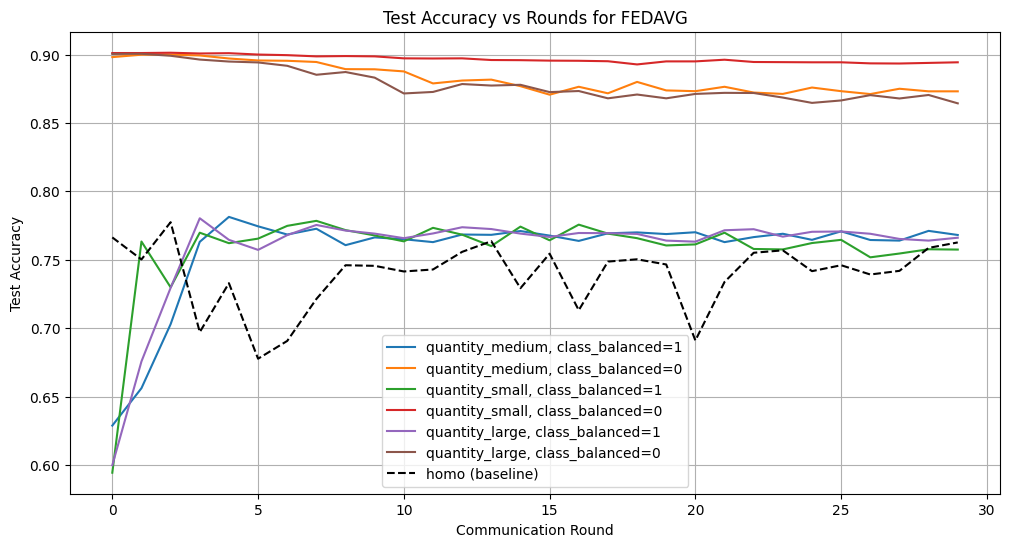

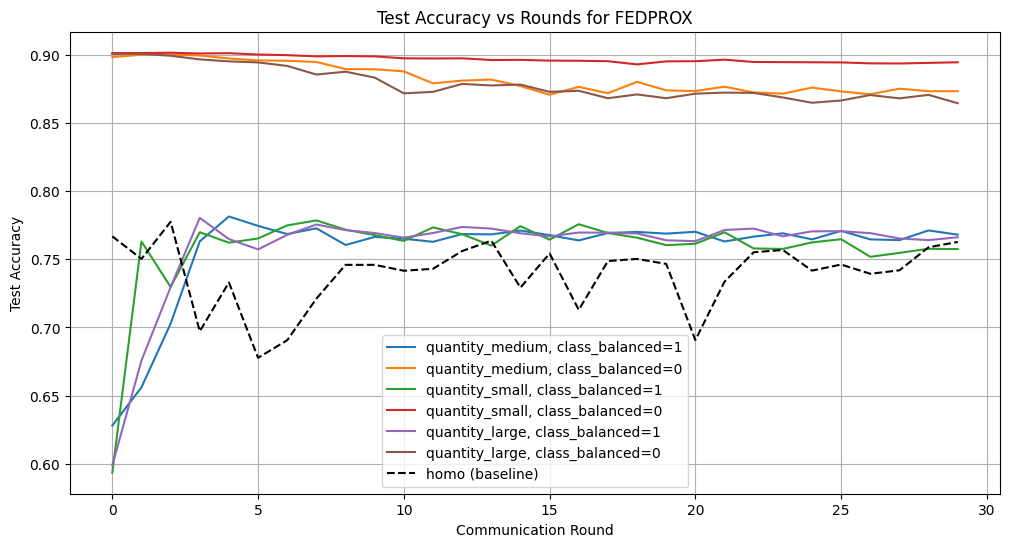

In [33]:
for alg in algorithms:
    plt.figure(figsize=(12, 6))
    for q in quantities:
        for cb in class_balance_flags:
            fname = result_file(alg, q, cb)
            if not os.path.exists(fname):
                print(f"Missing: {fname}")
                continue
            result = load_result(fname)
            label = f"{q}, class_balanced={cb}"
            plt.plot(result['round'], result['test_acc'], label=label)

    homo_file = f"results/{alg}_homo.pkl"
    if os.path.exists(homo_file):
        result = load_result(homo_file)
        plt.plot(result['round'], result['test_acc'], label='homo (baseline)', linestyle='--', color='black')

    plt.title(f"Test Accuracy vs Rounds for {alg.upper()}")
    plt.xlabel("Communication Round")
    plt.ylabel("Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

Test accuracy starts at around 90% for random class distributions and drops a bit with the number of communication rounds with small quantity being the most stable (ending with ~89.5%). In case of preserved class distributions the test accuracy increases rapidly at the beginning and stabilizes around round 5. Homogenous case shows more fluctuations probably due to some overfitting.

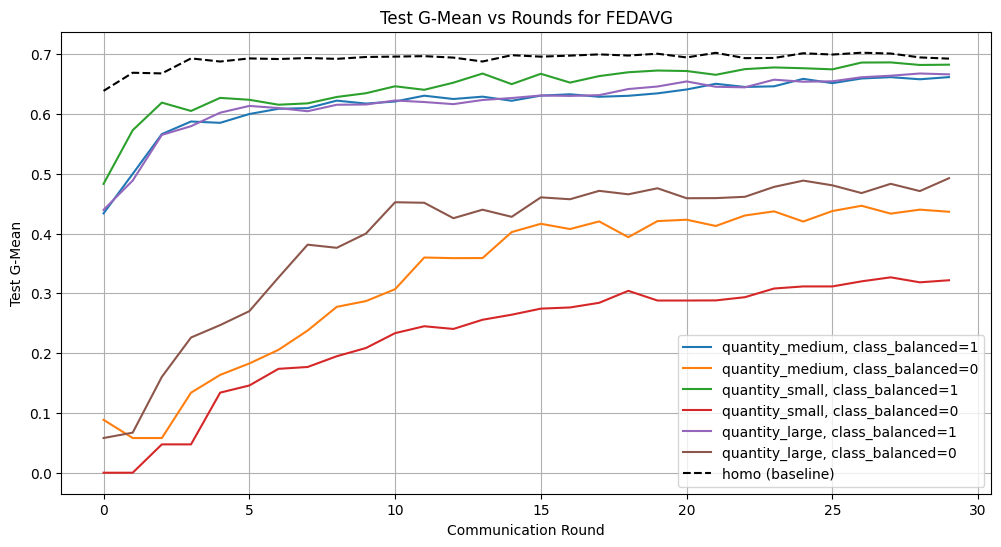

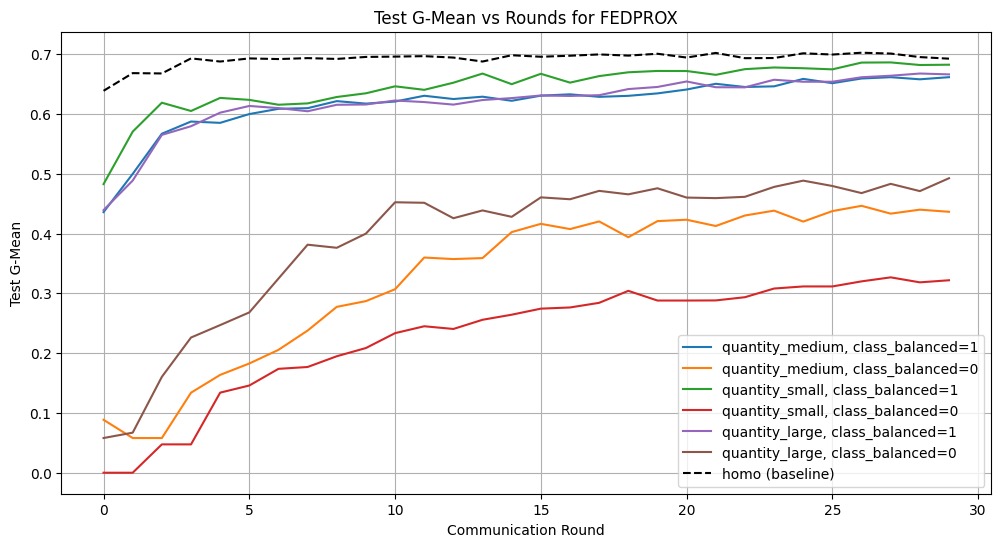

In [34]:
for alg in algorithms:
    plt.figure(figsize=(12, 6))
    for q in quantities:
        for cb in class_balance_flags:
            fname = result_file(alg, q, cb)
            if not os.path.exists(fname):
                print(f"Missing: {fname}")
                continue
            result = load_result(fname)
            label = f"{q}, class_balanced={cb}"
            plt.plot(result['round'], result['test_gmean'], label=label)

    homo_file = f"results/{alg}_homo.pkl"
    if os.path.exists(homo_file):
        result = load_result(homo_file)
        plt.plot(result['round'], result['test_gmean'], label='homo (baseline)', linestyle='--', color='black')

    plt.title(f"Test G-Mean vs Rounds for {alg.upper()}")
    plt.xlabel("Communication Round")
    plt.ylabel("Test G-Mean")
    plt.legend()
    plt.grid(True)
    plt.show()

Across all configurations, test g-mean improves rapidly during the initial rounds and generally stabilizes by round 10 (preserved class distribution) or 15 (random class distribution). Homogeneous (baseline) distributions tend to yield the highest final g-mean, reflecting the benefits of evenly distributed data. Among heterogeneous settings, class-balanced partitions (especially with small quantities) perform better than Dirichlet-imbalanced ones. Overall, data heterogeneity has a notable impact on convergence, underscoring the importance of both aggregation strategy and partitioning method in federated learning.

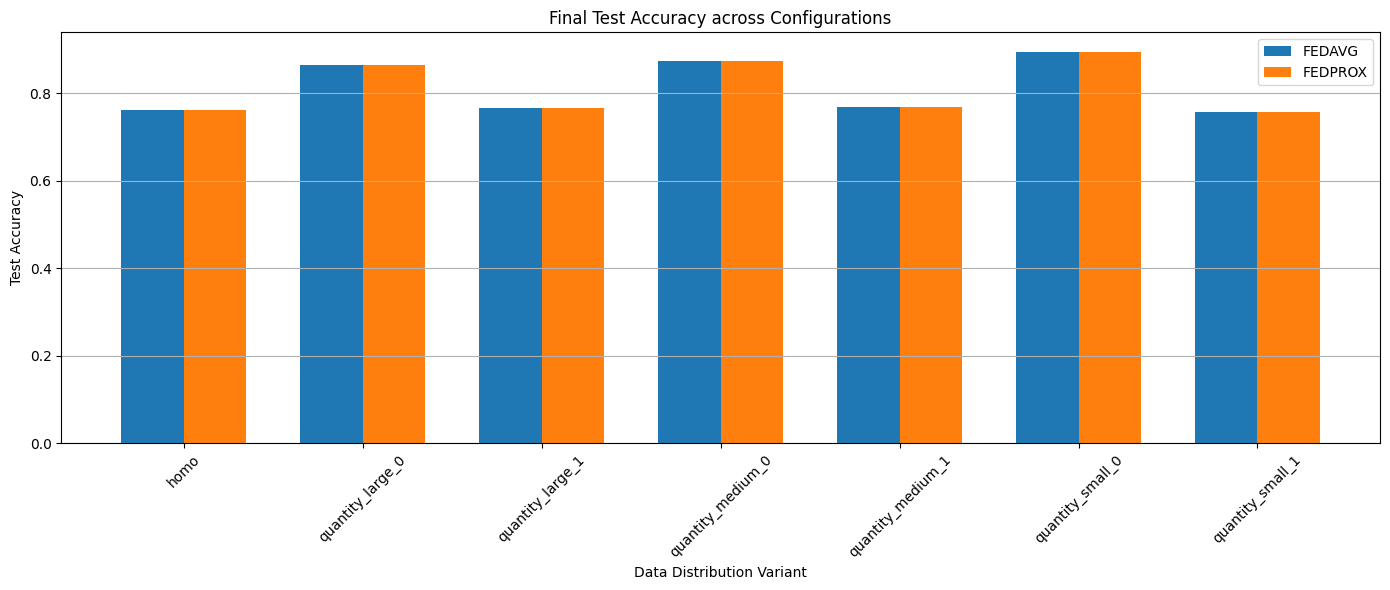

In [3]:
final_results = []

for alg in algorithms:
    for q in quantities:
        for cb in class_balance_flags:
            fname = result_file(alg, q, cb)
            if not os.path.exists(fname):
                continue
            result = load_result(fname)
            final_acc = result['test_acc'][-1]
            final_results.append((f"{q}_{cb}", alg, final_acc))

for alg in algorithms:
    fname = f"results/{alg}_homo.pkl"
    if os.path.exists(fname):
        result = load_result(fname)
        final_acc = result['test_acc'][-1]
        final_results.append(("homo", alg, final_acc))

distributions = sorted(set([x[0] for x in final_results]))
alg_set = sorted(set([x[1] for x in final_results]))
bar_width = 0.35
x = np.arange(len(distributions))

alg_acc = {alg: [] for alg in alg_set}
for dist in distributions:
    for alg in alg_set:
        acc = next((acc for d, a, acc in final_results if d == dist and a == alg), None)
        alg_acc[alg].append(acc if acc is not None else 0)

plt.figure(figsize=(14, 6))

for i, alg in enumerate(alg_set):
    offset = (i - 0.5) * bar_width
    plt.bar(x + offset, alg_acc[alg], width=bar_width, label=alg.upper())

plt.xticks(x, distributions, rotation=45)
plt.title("Final Test Accuracy across Configurations")
plt.ylabel("Test Accuracy")
plt.xlabel("Data Distribution Variant")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

The bar plot shows that the final test accuracy is higher for random class distribution, while final test accuracy for preserved class distribution is slightly higher than test accuracy for homogenous case (except for small quantity).

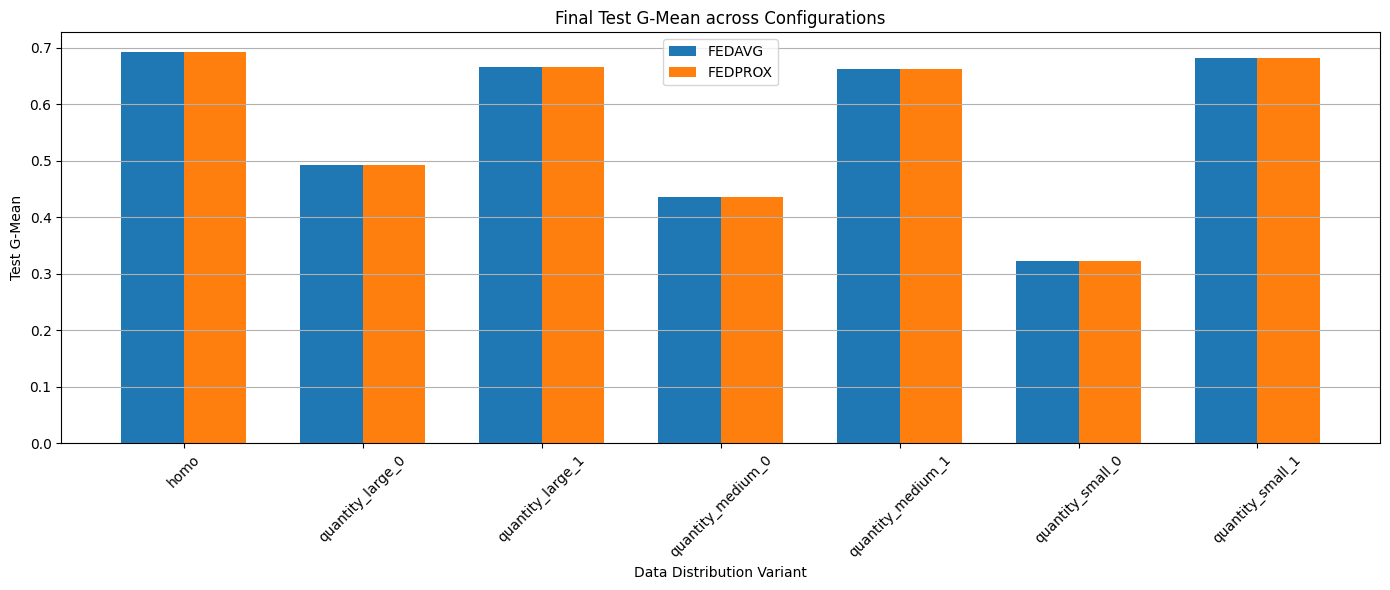

In [4]:
final_results = []

for alg in algorithms:
    for q in quantities:
        for cb in class_balance_flags:
            fname = result_file(alg, q, cb)
            if not os.path.exists(fname):
                continue
            result = load_result(fname)
            final_acc = result['test_gmean'][-1]
            final_results.append((f"{q}_{cb}", alg, final_acc))

for alg in algorithms:
    fname = f"results/{alg}_homo.pkl"
    if os.path.exists(fname):
        result = load_result(fname)
        final_acc = result['test_gmean'][-1]
        final_results.append(("homo", alg, final_acc))

distributions = sorted(set([x[0] for x in final_results]))
alg_set = sorted(set([x[1] for x in final_results]))
bar_width = 0.35
x = np.arange(len(distributions))

alg_acc = {alg: [] for alg in alg_set}
for dist in distributions:
    for alg in alg_set:
        acc = next((acc for d, a, acc in final_results if d == dist and a == alg), None)
        alg_acc[alg].append(acc if acc is not None else 0)

plt.figure(figsize=(14, 6))

for i, alg in enumerate(alg_set):
    offset = (i - 0.5) * bar_width
    plt.bar(x + offset, alg_acc[alg], width=bar_width, label=alg.upper())

plt.xticks(x, distributions, rotation=45)
plt.title("Final Test G-Mean across Configurations")
plt.ylabel("Test G-Mean")
plt.xlabel("Data Distribution Variant")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

This bar plot shows that the preserved class distributions achieve better final test g-mean than random class distributions. In particular small quantity which is almost as high as the baseline. Additionally, in random class distribution it can be seen that a predominance of cilents with large amount of data indicates higher final test g-mean which deacreases accordingly with medium and small amounts of data.